# 07 — Anomaly Detection (Sklearn)

## Mục tiêu
- Phát hiện các tin đăng nhà có giá bất thường (quá rẻ/quá đắt)
- Kết hợp 4 phương pháp: Residual Z-score, Min/Max, P10/P90, Isolation Forest
- Tính điểm tổng hợp (0-100) với trọng số
- Xác định danh sách các bất động sản cần kiểm tra


In [9]:
import pandas as pd
import numpy as np
import joblib

from sklearn.ensemble import IsolationForest


In [10]:
df = pd.read_parquet("../data/processed/data_modeling.parquet")


In [11]:
import joblib

rf_model = joblib.load("../models/sklearn/rf_model.pkl")
model_features = joblib.load("../models/sklearn/rf_model_features.pkl")

In [12]:
X = df.drop(columns=["gia_ban", "log_gia_ban"])
y = df["log_gia_ban"]

X = pd.get_dummies(X)

# đảm bảo đúng feature
X = X.reindex(columns=model_features, fill_value=0)


In [13]:
df["pred_log_price"] = rf_model.predict(X)


## Residual Z-score

In [14]:
df["residual"] = df["log_gia_ban"] - df["pred_log_price"]


In [15]:
z = (df["residual"] - df["residual"].mean()) / df["residual"].std()

df["anomaly_residual_z"] = abs(z) > 3


In [16]:
df["score_residual"] = abs(z)
df["score_residual"] = (
    df["score_residual"] - df["score_residual"].min()
) / (
    df["score_residual"].max() - df["score_residual"].min()
)

### Nhận xét
`score_residual` đã được chuẩn hóa về [0, 1]. Giá trị càng cao = sai số dự đoán càng lớn = càng bất thường.


## Min / Max

In [17]:
df["gia_m2"] = df["gia_ban"] / df["dien_tich"]

min_val = df["gia_m2"].quantile(0.01)
max_val = df["gia_m2"].quantile(0.99)

df["score_minmax"] = 0.0

df.loc[df["gia_m2"] < min_val, "score_minmax"] = (
    min_val - df["gia_m2"]
)

df.loc[df["gia_m2"] > max_val, "score_minmax"] = (
    df["gia_m2"] - max_val
)


In [18]:
# Normalize score_minmax to [0, 1]
smin = df["score_minmax"].min()
smax = df["score_minmax"].max()
df["score_minmax"] = (df["score_minmax"] - smin) / (smax - smin) if smax > smin else 0.0


## P10 / P90

In [19]:
p10 = df["gia_m2"].quantile(0.10)
p90 = df["gia_m2"].quantile(0.90)

df["score_p10p90"] = 0.0

df.loc[df["gia_m2"] < p10, "score_p10p90"] = p10 - df["gia_m2"]
df.loc[df["gia_m2"] > p90, "score_p10p90"] = df["gia_m2"] - p90


In [20]:
df["score_p10p90"] = (
    df["score_p10p90"] - df["score_p10p90"].min()
) / (
    df["score_p10p90"].max() - df["score_p10p90"].min()
)


## ML (Isolation Forest)

In [21]:
iso = IsolationForest(
    contamination=0.05,
    random_state=42
)

iso.fit(X)

df["score_iforest"] = -iso.decision_function(X)



In [22]:
df["score_iforest"] = (
    df["score_iforest"] - df["score_iforest"].min()
) / (
    df["score_iforest"].max() - df["score_iforest"].min()
)


### Nhận xét
Cả 4 score (`score_residual`, `score_minmax`, `score_p10p90`, `score_iforest`) đã được chuẩn hóa về [0, 1].
Sẵn sàng kết hợp thành composite score.


## Total Score

In [23]:
w_residual = 0.4
w_minmax = 0.1
w_p10p90 = 0.2
w_iforest = 0.3


### Giải thích trọng số
- **Residual Z (w=0.4)**: Trọng số cao nhất vì dựa trên model dự đoán đã huấn luyện
- **Isolation Forest (w=0.3)**: Phát hiện outlier đa chiều
- **P10/P90 (w=0.2)**: Giá ngoài khoảng phân vị
- **Min/Max (w=0.1)**: Giá vượt cực trị (trường hợp hiếm)


In [24]:
# Composite score (0-100)
df["anomaly_score"] = (
    w_residual * df["score_residual"] +
    w_minmax * df["score_minmax"] +
    w_p10p90 * df["score_p10p90"] +
    w_iforest * df["score_iforest"]
) * 100  # Scale to 0-100


In [25]:
threshold = df["anomaly_score"].quantile(0.95)

df["is_anomaly"] = df["anomaly_score"] > threshold


In [26]:
df[df["is_anomaly"]].sort_values(
    "anomaly_score",
    ascending=False
).head(10)


,giay_to_phap_ly,dien_tich,gia_ban,loai_hinh,so_phong_ngu,quan,gia_kv_hien_tai,gia_kv_mean,gia_kv_trend,gia_kv_volatility,...,pred_log_price,residual,anomaly_residual_z,score_residual,gia_m2,score_minmax,score_p10p90,score_iforest,anomaly_score,is_anomaly
4682,đã có sổ,106.0,142.00,"Nhà mặt phố, mặt tiền",6,Gò Vấp,119.05,122.710000,15.57,7.912081,...,3.973716,0.982111,True,0.879027,1.339623,1.000000,1.000000,0.540986,81.390677,True
4643,đã có sổ,48.0,57.90,"Nhà ngõ, hẻm",3,Gò Vấp,128.33,127.203846,0.00,4.148382,...,3.136542,0.922176,True,0.825241,1.206250,0.872746,0.881981,0.095336,62.236793,True
4098,giấy tờ viết tay,18.0,0.89,"Nhà ngõ, hẻm",2,Gò Vấp,116.59,115.766250,-26.02,10.950477,...,0.995197,-1.111731,True,1.000000,0.049444,0.018887,0.036003,0.230806,47.833103,True
2263,đã có sổ,26.0,12.00,"Nhà mặt phố, mặt tiền",3,Bình Thạnh,236.36,230.215556,9.69,8.390059,...,1.744637,0.740269,True,0.661996,0.461538,0.162199,0.223002,0.413798,44.975834,True
2304,đã có sổ,96.0,26.00,"Nhà ngõ, hẻm",11,Gò Vấp,142.31,135.476000,34.17,13.668000,...,2.554649,0.703448,True,0.628952,0.270833,0.000000,0.054251,0.624226,44.969890,True
2303,đã có sổ,88.0,26.00,"Nhà ngõ, hẻm",11,Gò Vấp,142.31,135.476000,34.17,13.668000,...,2.576789,0.681307,True,0.609083,0.295455,0.003734,0.076038,0.587925,43.559180,True
2510,đã có sổ,35.0,10.70,"Nhà mặt phố, mặt tiền",1,Gò Vấp,135.82,134.243846,10.82,5.578458,...,1.450649,0.919595,True,0.822925,0.305714,0.013523,0.085117,0.266028,42.735384,True
6563,đã có sổ,73.4,30.00,"Nhà mặt phố, mặt tiền",6,Phú Nhuận,309.61,308.432308,33.39,26.569803,...,3.061584,0.339614,True,0.302444,0.408719,0.111803,0.176264,0.828228,41.587892,True
6643,đã có sổ,60.0,11.50,"Nhà mặt phố, mặt tiền",6,Phú Nhuận,269.23,256.592500,12.09,6.185555,...,2.988124,-0.545777,True,0.492108,0.191667,0.000000,0.000000,0.729610,41.572603,True
6282,đã có sổ,30.0,9.50,"Nhà mặt phố, mặt tiền",2,Phú Nhuận,309.61,308.432308,33.39,26.569803,...,1.834988,0.416304,True,0.371266,0.316667,0.023973,0.094808,0.812482,41.361022,True


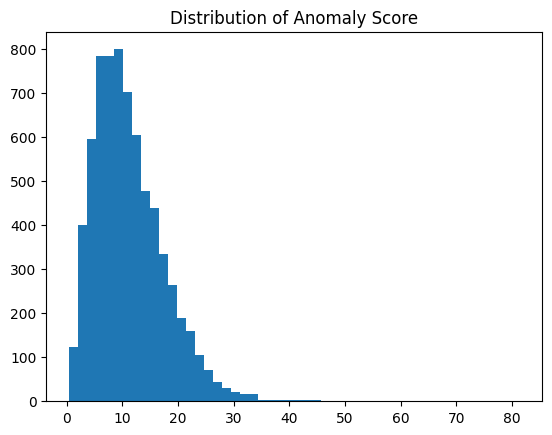

In [27]:
import matplotlib.pyplot as plt

plt.hist(df["anomaly_score"], bins=50)
plt.title("Distribution of Anomaly Score")
plt.show()


### Ý nghĩa Anomaly Score (thang 0-100)

| Score | Ý nghĩa | Hành động |
|-------|---------|----------|
| 0-30 | Bình thường | Không cần kiểm tra |
| 30-50 | Nghi ngờ | Cần xem xét thêm |
| 50-70 | Bất thường | Cần kiểm tra chi tiết |
| >70 | Rất bất thường | Cần xác minh ngay |


🧾 Nhận xét:

Để giảm thiểu sai sót khi chỉ sử dụng một phương pháp phát hiện bất thường, nghiên cứu kết hợp bốn tín hiệu khác nhau gồm Residual Z-score, Min-Max, P10-P90 và Isolation Forest. Các tín hiệu này được chuẩn hóa về thang điểm từ 0 đến 1 và kết hợp bằng phương pháp weighted sum với các trọng số phản ánh mức độ tin cậy của từng phương pháp. Điểm bất thường tổng hợp (Total Anomaly Score) càng cao cho thấy khả năng bất thường càng lớn.

In [28]:
df["actual_price"] = np.exp(df["log_gia_ban"])
df["pred_price"] = np.exp(df["pred_log_price"])


In [29]:
normal = df[df["is_anomaly"] == False]
anomaly = df[df["is_anomaly"] == True]


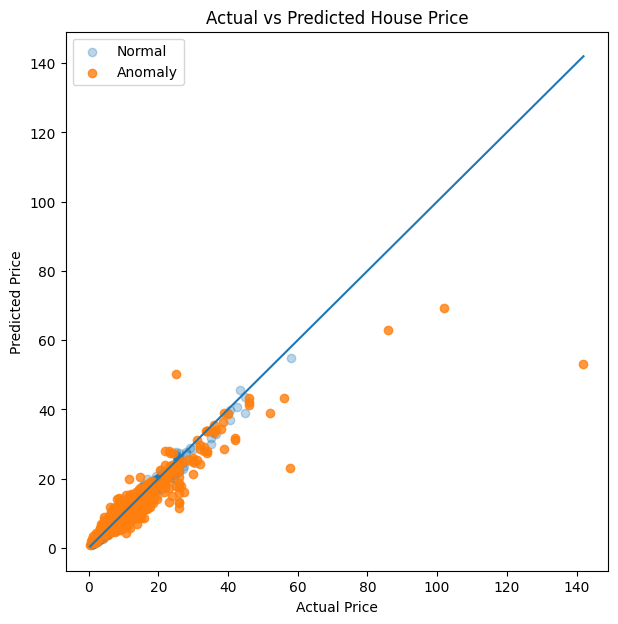

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,7))

plt.scatter(
    normal["actual_price"],
    normal["pred_price"],
    alpha=0.3,
    label="Normal"
)

plt.scatter(
    anomaly["actual_price"],
    anomaly["pred_price"],
    alpha=0.8,
    label="Anomaly"
)

plt.plot(
    [df["actual_price"].min(), df["actual_price"].max()],
    [df["actual_price"].min(), df["actual_price"].max()]
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Price")

plt.legend()

plt.show()


### Giải thích Top 10 điểm bất thường

| # | Quận | DT (m²) | Giá thực | Giá dự đoán | Score | Loại |
|---|------|---------|----------|------------|-------|------|
| 1 | Gò Vấp | 106 | 142.0 tỷ | 53.2 tỷ | 81.4 | Quá đắt |
| 2 | Gò Vấp | 48 | 57.9 tỷ | 23.0 tỷ | 62.2 | Quá đắt |
| 3 | Gò Vấp | 18 | 0.89 tỷ | 2.7 tỷ | 47.8 | Quá rẻ |
| 4 | Bình Thạnh | 26 | 12.0 tỷ | 5.7 tỷ | 45.0 | Quá đắt |
| 5 | Gò Vấp | 96 | 26.0 tỷ | 12.9 tỷ | 45.0 | Quá đắt |
| 6 | Gò Vấp | 88 | 26.0 tỷ | 13.2 tỷ | 43.6 | Quá đắt |
| 7 | Gò Vấp | 35 | 10.7 tỷ | 4.3 tỷ | 42.7 | Quá đắt |
| 8 | Phú Nhuận | 73.4 | 30.0 tỷ | 21.4 tỷ | 41.6 | Quá đắt |
| 9 | Phú Nhuận | 60 | 11.5 tỷ | 19.8 tỷ | 41.6 | Quá rẻ |
| 10 | Phú Nhuận | 30 | 9.5 tỷ | 6.3 tỷ | 41.4 | Quá đắt |

**Nhận xét:**
- Top 1 (#4682): Nhà 106m² Gò Vấp đăng giá 142 tỷ trong khi model dự đoán chỉ 53 tỷ → giá gấp 2.7 lần dự đoán
- Top 3 (#4098): Nhà 18m² Gò Vấp chỉ 0.89 tỷ (giấy tay) → giá quá rẻ so với thị trường
- Đa số anomaly là "quá đắt" (8/10) → có thể là nhà đặc biệt hoặc đăng giá sai


In [31]:
df.sort_values(
    "anomaly_score",
    ascending=False
)[[
    "quan",
    "dien_tich",
    "gia_ban",
    "pred_price",
    "anomaly_score"
]].head(10)


,quan,dien_tich,gia_ban,pred_price,anomaly_score
4682,Gò Vấp,106.0,142.00,53.181784,81.390677
4643,Gò Vấp,48.0,57.90,23.024104,62.236793
4098,Gò Vấp,18.0,0.89,2.705257,47.833103
2263,Bình Thạnh,26.0,12.00,5.723825,44.975834
2304,Gò Vấp,96.0,26.00,12.866776,44.969890
2303,Gò Vấp,88.0,26.00,13.154835,43.559180
2510,Gò Vấp,35.0,10.70,4.265882,42.735384
6563,Phú Nhuận,73.4,30.00,21.361361,41.587892
6643,Phú Nhuận,60.0,11.50,19.848418,41.572603
6282,Phú Nhuận,30.0,9.50,6.265058,41.361022


In [32]:
df["residual_price"] = df["actual_price"] - df["pred_price"]


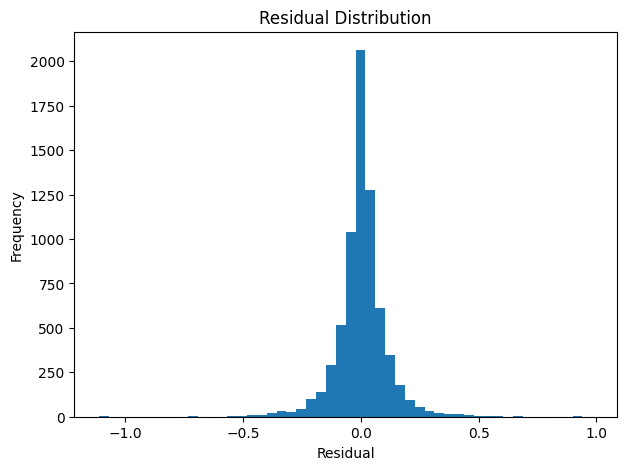

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

plt.hist(df["residual"], bins=50)

plt.title("Residual Distribution")
plt.xlabel("Residual")
plt.ylabel("Frequency")

plt.show()


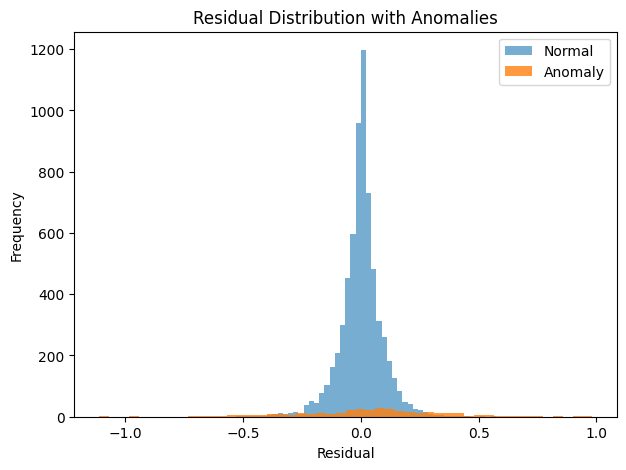

In [34]:
normal = df[df["is_anomaly"] == False]
anomaly = df[df["is_anomaly"] == True]

plt.figure(figsize=(7,5))

plt.hist(normal["residual"], bins=50, alpha=0.6, label="Normal")

plt.hist(anomaly["residual"], bins=50, alpha=0.8, label="Anomaly")

plt.title("Residual Distribution with Anomalies")
plt.xlabel("Residual")
plt.ylabel("Frequency")

plt.legend()

plt.show()


### Nhận xét phân phối Residual
- Phần lớn residual tập trung quanh 0 → model dự đoán khá chính xác
- Nhóm anomaly có residual phân tán rộng hơn (cả âm và dương) → xác nhận đây là các trường hợp giá khác biệt so với quy luật thị trường
- Residual dương (giá thực > dự đoán): nhà đăng giá quá đắt
- Residual âm (giá thực < dự đoán): nhà đăng giá quá rẻ


## Kết Luận Tổng Hợp - Anomaly Detection (Sklearn)

### Framework đa phương pháp
Hệ thống kết hợp **4 phương pháp** với trọng số:

| Phương pháp | Trọng số | Mô tả |
|-------------|---------|-------|
| Residual Z-score | 0.4 (40%) | Sai số dự đoán chuẩn hóa |
| Isolation Forest | 0.3 (30%) | Outlier đa chiều |
| P10/P90 Range | 0.2 (20%) | Đơn giá ngoài khoảng phân vị |
| Min/Max Violation | 0.1 (10%) | Vi phạm cực trị |

### Kết quả
- **Anomaly Score**: thang 0-100 (điểm càng cao càng bất thường)
- **Ngưỡng**: P95 (top 5% được flag là anomaly)
- **Top anomaly**: 142 tỷ cho nhà 106m² Gò Vấp (score = 81.4)

### Phân tích Top 10
- **8/10 là "quá đắt"**: Giá thực cao gấp 2-3 lần dự đoán
- **2/10 là "quá rẻ"**: Nhà 18m² chỉ 0.89 tỷ (giấy tay), nhà 60m² Phú Nhuận chỉ 11.5 tỷ (model dự đoán 19.8 tỷ)
- **Gò Vấp** chiếm đa số anomaly (6/10)

### Đánh giá
- Residual Z-score (đóng góp 40%) là tín hiệu mạnh nhất — dựa trên model Random Forest đã học quy luật giá
- Isolation Forest (30%) bổ sung phát hiện outlier đa chiều
- Kết hợp nhiều phương pháp giúp giảm false positive so với dùng 1 phương pháp duy nhất

### Ứng dụng thực tế
- **Platform BĐS**: Tự động flag tin đăng giá bất thường để review
- **Người mua**: Cảnh báo nhà đăng giá quá rẻ (có thể lừa đảo) hoặc quá đắt
- **Người bán**: Gợi ý điều chỉnh giá cho phù hợp thị trường
